In [1]:
#Теркалов Андрей Сергеевич
#Face Detectors: MTCNN 
#Face recognition models: DeepID

In [23]:
import cv2
import numpy as np
from mtcnn import MTCNN
from scipy.spatial.distance import euclidean
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input

In [24]:
def build_deepid(input_shape=(55, 47, 3)):
    inp = Input(shape=input_shape)
    x = Flatten()(inp)
    x = Dense(512, activation='relu')(x)
    x = Dense(160, activation=None)(x)  
    model = Model(inputs=inp, outputs=x)
    return model

detector = MTCNN()

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\redmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\redmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\redmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


In [25]:
deepid_model = build_deepid()
deepid_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 55, 47, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7755)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,971,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 160)                 │          82,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,053,152 (15.46 MB)

 Trainable params: 4,053,152 (15.46 MB)

 Non-trainable params: 0 (0.00 B)

(np.float64(-0.5), np.float64(46.5), np.float64(54.5), np.float64(-0.5))

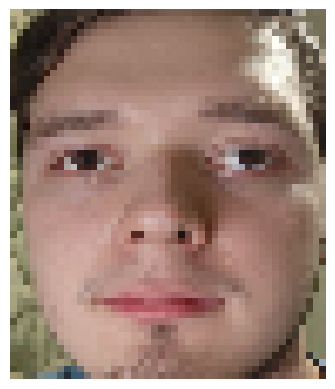

In [41]:
def l2_normalize(vec, eps=1e-10):
    norm = np.linalg.norm(vec)
    return vec / (norm + eps)

image = cv2.imread("me.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

faces = detector.detect_faces(image_rgb)

x, y, w, h = faces[0]['box']
face = image_rgb[y:y+h, x:x+w]
face = cv2.resize(face, (47, 55))

plt.imshow(face)
plt.axis("off")

In [35]:
face_norm = face / 255.0
face_input = np.expand_dims(face_norm, axis=0)

reference_embedding = deepid_model.predict(face_input)
reference_embedding = l2_normalize(reference_embedding)
print("Размер эмбеддинга:", reference_embedding.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Размер эмбеддинга: (1, 160)


In [36]:
#Евклидова близость
def compare_faces(emb1, emb2):
    return euclidean(emb1.flatten(), emb2.flatten())

In [37]:
cap = cv2.VideoCapture(0)

NUM_FRAMES = 10

for i in range(NUM_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(rgb)

    for f in faces:
        x, y, w, h = f['box']
        face_cam = rgb[y:y+h, x:x+w]
        face_cam = cv2.resize(face_cam, (47, 55))
        face_cam = face_cam / 255.0
        face_cam = np.expand_dims(face_cam, axis=0)

        emb = deepid_model.predict(face_cam)
        emb = l2_normalize(emb)

        dist = compare_faces(reference_embedding, emb)
        print(f"Кадр {i}: Евклидово расстояние = {dist:.3f}")

cap.release()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Кадр 0: Евклидово расстояние = 0.398
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Кадр 1: Евклидово расстояние = 0.373
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Кадр 2: Евклидово расстояние = 0.376
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Кадр 3: Евклидово расстояние = 0.379
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Кадр 4: Евклидово расстояние = 0.375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Кадр 5: Евклидово расстояние = 0.363
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Кадр 6: Евклидово расстояние = 0.365
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Кадр 7: Евклидово расстояние = 0.383
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Кадр 8: Евклидово расстояние = 0.389
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Кадр 9: Евклидово расстояние = 0.395


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Евклидово расстояние (наклон головы): 0.47396156191825867


(np.float64(-0.5), np.float64(959.5), np.float64(1279.5), np.float64(-0.5))

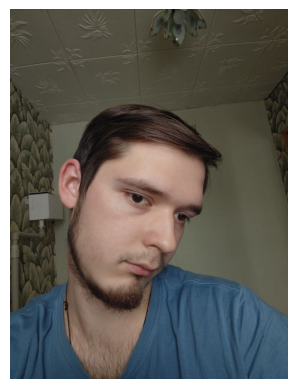

In [42]:
# Фото с наклоном головы
tilt_img = cv2.imread("me_tilt.jpg")
tilt_rgb = cv2.cvtColor(tilt_img, cv2.COLOR_BGR2RGB)

faces = detector.detect_faces(tilt_rgb)

x, y, w, h = faces[0]['box']
tilt_face = tilt_rgb[y:y+h, x:x+w]
tilt_face = cv2.resize(tilt_face, (47, 55))
tilt_face = tilt_face / 255.0
tilt_face = np.expand_dims(tilt_face, axis=0)

tilt_embedding = deepid_model.predict(tilt_face)
tilt_embedding = l2_normalize(tilt_embedding)

distance = compare_faces(reference_embedding, tilt_embedding)
print("Евклидово расстояние (наклон головы):", distance)
plt.imshow(tilt_rgb)
plt.axis("off")

In [43]:
#Модель достаточно устойчива к повороту и наклону головы